Load dataset

In [5]:
import pandas as pd

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
train = pd.read_csv('/content/drive/MyDrive/Datasets/MNIST/mnist_train.csv')
test = pd.read_csv('/content/drive/MyDrive/Datasets/MNIST/mnist_test.csv')

In [8]:
X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values

In [9]:
X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

In [10]:
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [11]:
print(y_train.shape)
print(y_test.shape)

(60000,)
(10000,)


In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [13]:
import matplotlib.pyplot as plt

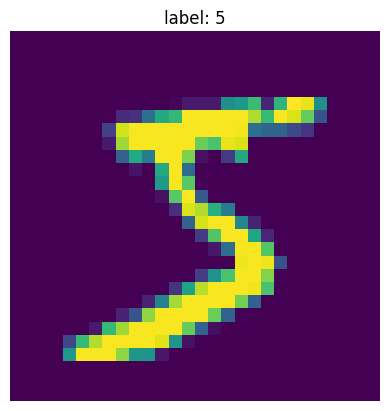

In [15]:
index = 0

image = X_train[index]
label = y_train[index]

plt.imshow(image.reshape(28, 28))
plt.title(f"label: {label}")
plt.axis("off")
plt.show()

PCA

In [16]:
from sklearn.decomposition import PCA

In [17]:
n_components = 5

In [18]:
pca = PCA(n_components = n_components)

In [19]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

reconstruction

In [20]:
X_test_pca_reconstructed = pca.inverse_transform(X_test_pca)

In [21]:
from sklearn.metrics import mean_squared_error

In [22]:
pca_error = mean_squared_error(X_test, X_test_pca_reconstructed)
print(pca_error)

0.044526432619148196


displaying image

In [23]:
index = 0

In [24]:
original = X_test[index]
reconstructed = X_test_pca_reconstructed[index]

In [25]:
original = original.reshape(28,28)
reconstructed = reconstructed.reshape(28,28)

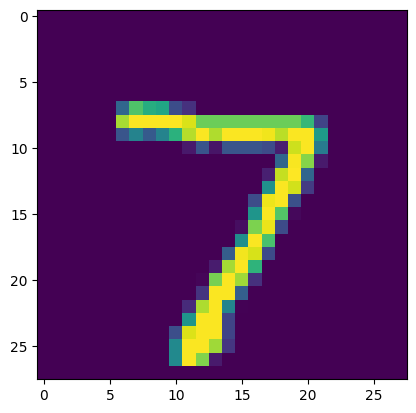

In [26]:
plt.imshow(original)

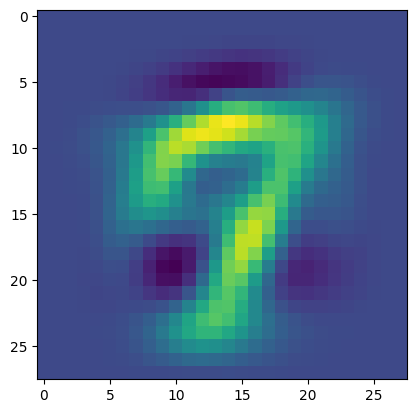

In [27]:
plt.imshow(reconstructed)

autoencoder

In [28]:
input_dim = 784
encoding_dim = 5

In [29]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [30]:
input_layer = Input(shape=(input_dim,))

encoder = Dense(128, activation = "relu")(input_layer)
encoder = Dense(encoding_dim, activation = "relu")(encoder)

decoder = Dense(128, activation="relu")(encoder)
decoder = Dense(input_dim, activation = "sigmoid")(decoder)

In [31]:
autoencoder = Model(input_layer, decoder)

In [32]:
autoencoder.compile(optimizer = Adam(), loss = "mse")

In [33]:
autoencoder.fit(X_train, X_train, epochs = 10, batch_size = 256, shuffle = True, validation_data = (X_test, X_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0989 - val_loss: 0.0487
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0463 - val_loss: 0.0390
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0385 - val_loss: 0.0357
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0357 - val_loss: 0.0342
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0341 - val_loss: 0.0330
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0332 - val_loss: 0.0323
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0323 - val_loss: 0.0316
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0319 - val_loss: 0.0312
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0314 - val_loss: 0.0309
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0310 - val_loss: 0.0306


reconstruction

In [34]:
X_test_ae = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [35]:
ae_error = mean_squared_error(X_test, X_test_ae)
print(ae_error)

0.030586469567278483


displaying image

In [36]:
index = 0

In [37]:
original = X_test[index]
reconstructed = X_test_ae[index]

In [38]:
original = original.reshape(28,28)
reconstructed = reconstructed.reshape(28,28)

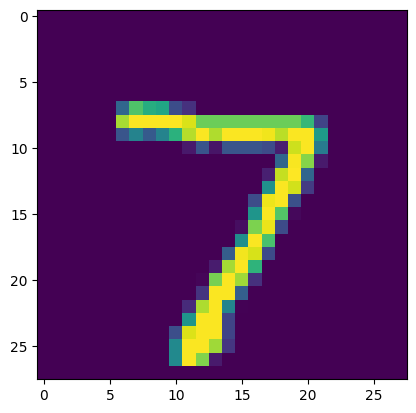

In [39]:
plt.imshow(original)

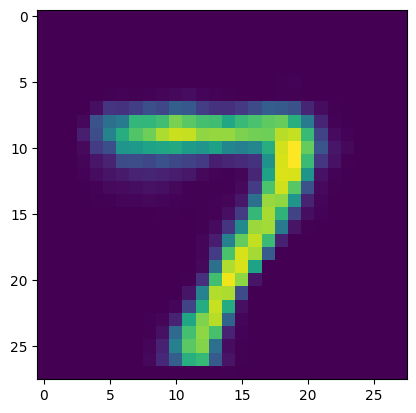

In [40]:
plt.imshow(reconstructed)